Extended Data Figure 13 — Cell fate probabilities across leukemic trajectories in Patient 1.

Patient 1 (03H096 / PB2). ForceAtlas2 of MultiVI space, colored by MIRA fate probability of reaching T1 (a) or T2 (b). Higher probability = lighter (`magma`). Red arrows = CSC/Root (cluster 6).

MIRA `mira-multiome` 2.1.1, as in Methods: diffusion map → `normalize_diffmap` → first 7 DCs → 50 neighbors on that representation → connected components → transport map from the DPT start cell (cluster 6, index 2) → `find_terminal_cells(seed=3, iterations=10, threshold=1e-2)` → branch probabilities named T1 (cluster 5) and T2 (cluster 2).

`DATA` = TALL_Review root.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scanpy as sc
import muon
import mira

# NetworkX 3 dropped from_scipy_sparse_matrix; MIRA 2.1.1 still calls it.
if not hasattr(nx.convert_matrix, "from_scipy_sparse_matrix"):
    nx.convert_matrix.from_scipy_sparse_matrix = nx.from_scipy_sparse_array

DATA = Path("PATH_TO_DATA")
sc.set_figure_params(dpi=100, fontsize=12, frameon=False, figsize=(6.4, 4.8))
FA_SIZE = 100

ROOT_CLUSTER = "6"
ROOT_INDEX = 2
T1_CLUSTER = "5"  # KLRG1-high
T2_CLUSTER = "2"  # CD9-high CD54-high
N_DCS = 7
N_NEIGHBORS = 50


In [2]:
adata = sc.read_h5ad(DATA / "TALL_Website/Object/PB2/Teaseq_Multi_VI_PB2_Cleaned.h5ad")
adata.obs["Cluster_Final"] = adata.obs["Cluster_Final"].astype(str).astype("category")

root_indices = np.flatnonzero(adata.obs["Cluster_Final"].astype(str) == ROOT_CLUSTER)
start_ix = int(root_indices[ROOT_INDEX] if len(root_indices) > ROOT_INDEX else root_indices[0])
start_cell = adata.obs_names[start_ix]
print(f"Start cell (Root cluster {ROOT_CLUSTER}, index {ROOT_INDEX}): {start_cell}")


Start cell (Root cluster 6, index 2): AAATGGCCAGCCAGAA-5_PB2


## MIRA fate probabilities


In [3]:
sc.tl.diffmap(adata)
mira.time.normalize_diffmap(adata)
adata.obsm["X_diffmap"] = np.asarray(adata.obsm["X_diffmap"])[:, :N_DCS]
sc.pp.neighbors(adata, use_rep="X_diffmap", n_neighbors=N_NEIGHBORS, key_added="X_diffmap")
mira.time.get_connected_components(adata)

start_comp = str(adata.obs.loc[start_cell, "mira_connected_components"])
n_comp = adata.obs["mira_connected_components"].nunique()
print(f"Connected components: {n_comp}; keeping start-cell component {start_comp}")
if n_comp > 1:
    adata = adata[adata.obs["mira_connected_components"].astype(str) == start_comp].copy()

mira.time.get_transport_map(adata, start_cell=start_cell, n_jobs=8)

terminal_cells = list(
    mira.time.find_terminal_cells(adata, seed=3, iterations=10, threshold=1e-2)
)
print("Terminal cells:", ", ".join(map(str, terminal_cells)))
print(adata.obs.loc[terminal_cells, ["Cluster_Final", "mira_pseudotime"]])


def pick_terminus(cluster, candidates):
    cl = adata.obs["Cluster_Final"].astype(str)
    in_cluster = [c for c in candidates if str(cl.loc[c]) == str(cluster)]
    if in_cluster:
        return max(in_cluster, key=lambda c: float(adata.obs.loc[c, "mira_pseudotime"]))
    sub = adata.obs_names[cl == str(cluster)]
    return sub[int(np.argmax(adata.obs.loc[sub, "mira_pseudotime"].to_numpy()))]


termini = {
    "T1": pick_terminus(T1_CLUSTER, terminal_cells),
    "T2": pick_terminus(T2_CLUSTER, terminal_cells),
}
print("Named termini:", termini)
print(adata.obs.loc[list(termini.values()), ["Cluster_Final", "mira_pseudotime"]])

mira.time.get_branch_probabilities(adata, terminal_cells=termini)
print(adata.obs[["T1_prob", "T2_prob"]].describe())


diffmap + normalize
X_diffmap shape (3863, 7)
Connected components: 1; keeping start-cell component 0
transport map
Terminal cells: ATGCAAACACCTGCCT-5_PB2, GTTCACCTCACTAAGC-5_PB2, GTTTGTTTCGTTATAG-5_PB2, CTCCGGACAATTTAGC-5_PB2, AGGATCCGTCATAACG-5_PB2
                       Cluster_Final  mira_pseudotime
ATGCAAACACCTGCCT-5_PB2             7         4.069037
GTTCACCTCACTAAGC-5_PB2             4         6.386865
GTTTGTTTCGTTATAG-5_PB2             2         7.117856
CTCCGGACAATTTAGC-5_PB2             5         7.861929
AGGATCCGTCATAACG-5_PB2             1         6.866627
Named termini: {'T1': 'CTCCGGACAATTTAGC-5_PB2', 'T2': 'GTTTGTTTCGTTATAG-5_PB2'}
                       Cluster_Final  mira_pseudotime
CTCCGGACAATTTAGC-5_PB2             5         7.861929
GTTTGTTTCGTTATAG-5_PB2             2         7.117856
           T1_prob      T2_prob
count  3863.000000  3863.000000
mean      0.567657     0.432081
std       0.347145     0.347096
min       0.000000     0.000000
25%       0.187876     

In [4]:
def add_root_arrow(ax, adata, cluster=ROOT_CLUSTER):
    fa = np.asarray(adata.obsm["X_draw_graph_fa"])
    mask = adata.obs["Cluster_Final"].astype(str).to_numpy() == str(cluster)
    xy = fa[mask].mean(axis=0)
    span = fa.max(axis=0) - fa.min(axis=0)
    start = xy + np.array([-0.14, 0.14]) * span
    ax.annotate(
        "",
        xy=xy,
        xytext=start,
        arrowprops=dict(arrowstyle="-|>", color="red", lw=1.8, mutation_scale=14),
    )


def plot_fate(adata, key, title):
    ax = muon.pl.embedding(
        adata,
        basis="X_draw_graph_fa",
        color=key,
        color_map="magma",
        frameon=False,
        size=FA_SIZE,
        title=title,
        show=False,
        colorbar_loc="right",
    )
    add_root_arrow(ax, adata)
    return ax


## (a) T1 fate probability


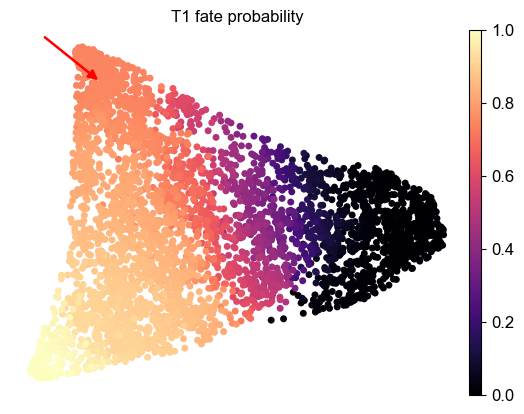

In [5]:
plot_fate(adata, "T1_prob", "T1 fate probability")


## (b) T2 fate probability


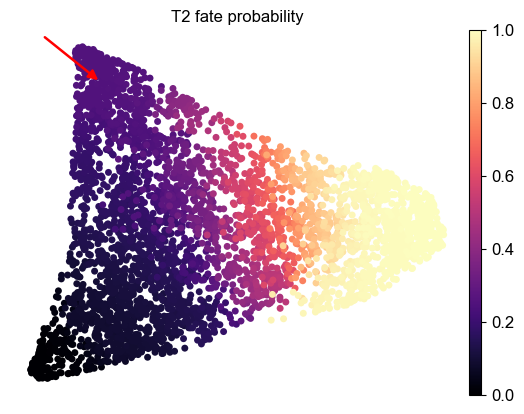

In [6]:
plot_fate(adata, "T2_prob", "T2 fate probability")
